In [1]:
import gempipe
import pandas as pnd

In [2]:
report = pnd.read_csv('gempipe/output_derive/derive_strains.csv', index_col=0)
report = report.rename(columns={'species':  'subsp.'})

# import binary feature tables:
biosynth = pnd.read_csv('gempipe/output_derive/biosynth.csv', index_col=0)
rpam = pnd.read_csv('gempipe/output_derive/rpam.csv', index_col=0)
feats = pnd.concat([biosynth, rpam], axis=0)


# select interesting metabolites:
feats = feats.loc[[
    'thf_c',  # vitamin B9  (tetrahydrofolate)
    'adeadocbl_c',  # vitamin B12
    '3hppnl_c',   # reuterin (3-hydroxypropanal)
    'hista_c',   # histamine (HISDC)
    'UREA',  # conversion urea → co2 + nh4
], :]
feats

,GCA_948817145.1,GCA_020785755.1,GCA_002254115.1,GCA_036432135.1,GCA_024622315.1,GCA_002128615.1,GCA_003174995.1,GCA_009649475.1,GCA_036431025.1,GCA_948624245.1,...,GCA_003174935.1,GCA_948962865.1,GCA_949483345.1,GCA_002253905.1,GCA_020784755.1,GCA_948858945.1,GCA_948693985.1,GCA_003174875.1,GCA_009389375.1,GCA_016294205.1
thf_c,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
adeadocbl_c,NaN,1.0,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,...,1.0,NaN,NaN,1.0,NaN,NaN,NaN,1.0,1.0,NaN
3hppnl_c,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
hista_c,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
UREA,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,...,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0


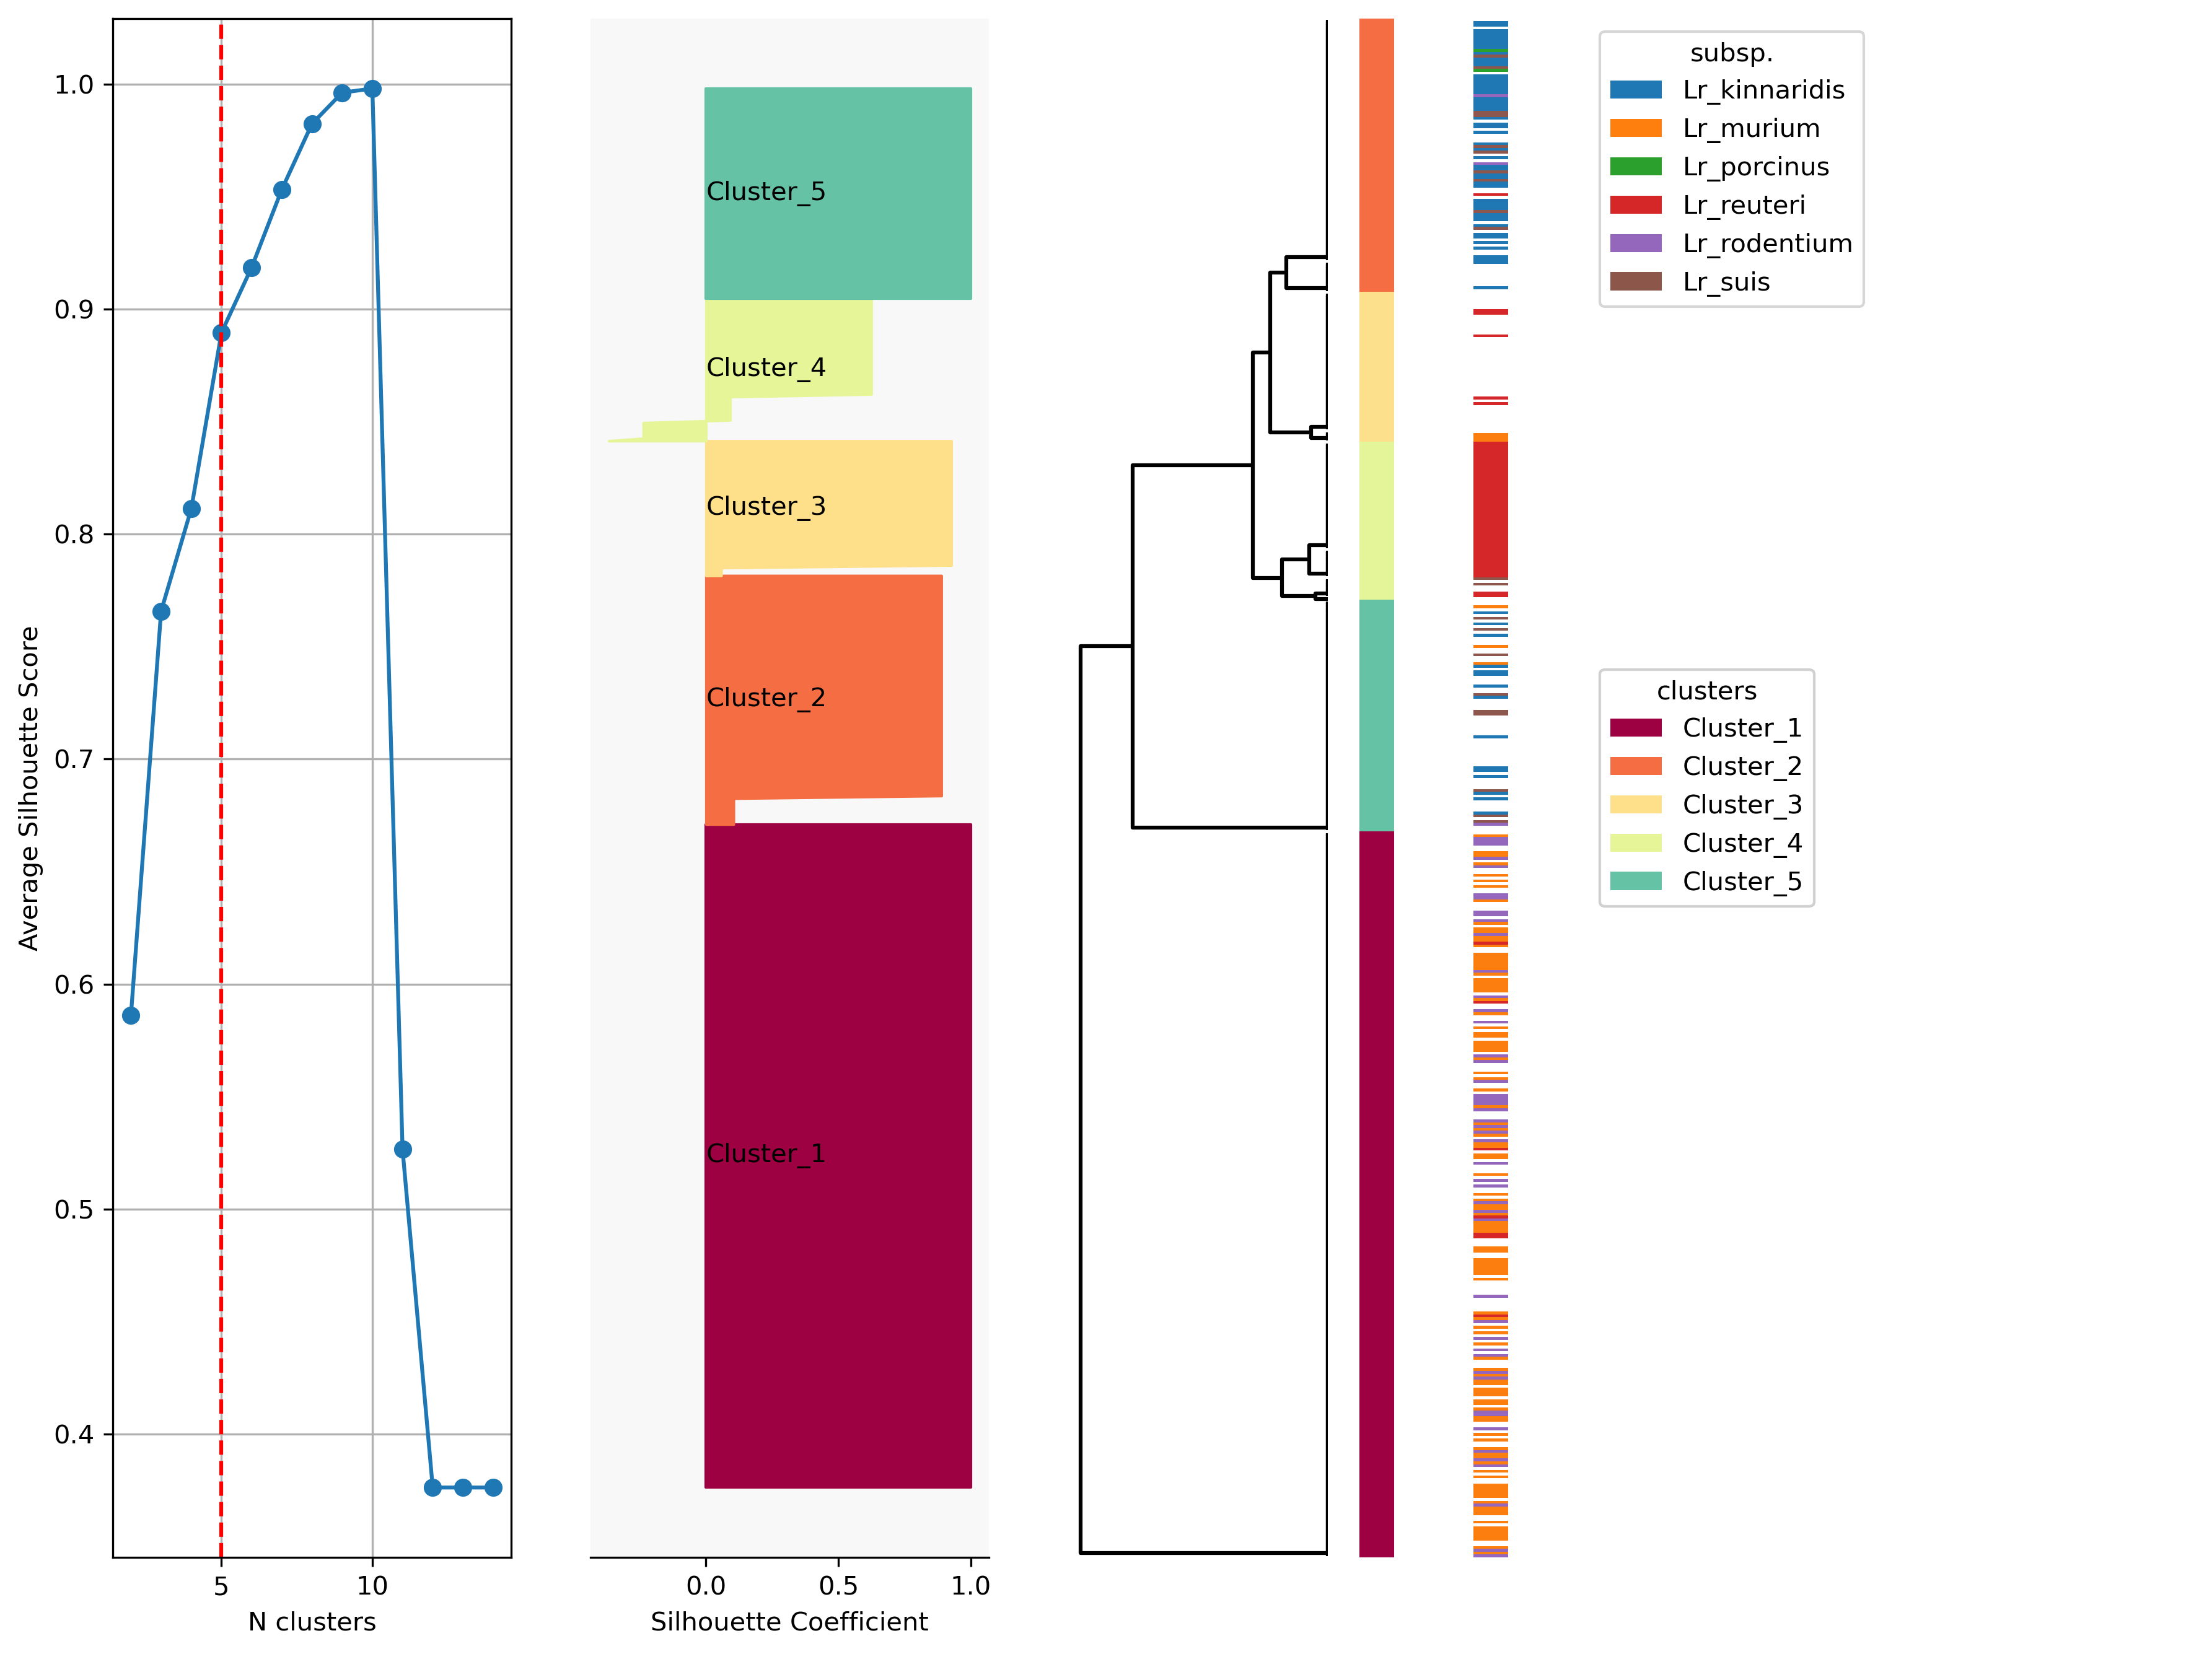

In [3]:
fig, acc_to_cluster, cluster_to_color = gempipe.silhouette_analysis( 
    figsize = (12,9), forcen=5, ctotest=range(2,15,1), 
    derive_report=report, report_key='subsp.', excludekeys=['other_Lr'],
    tables={'presence': feats}, 
)

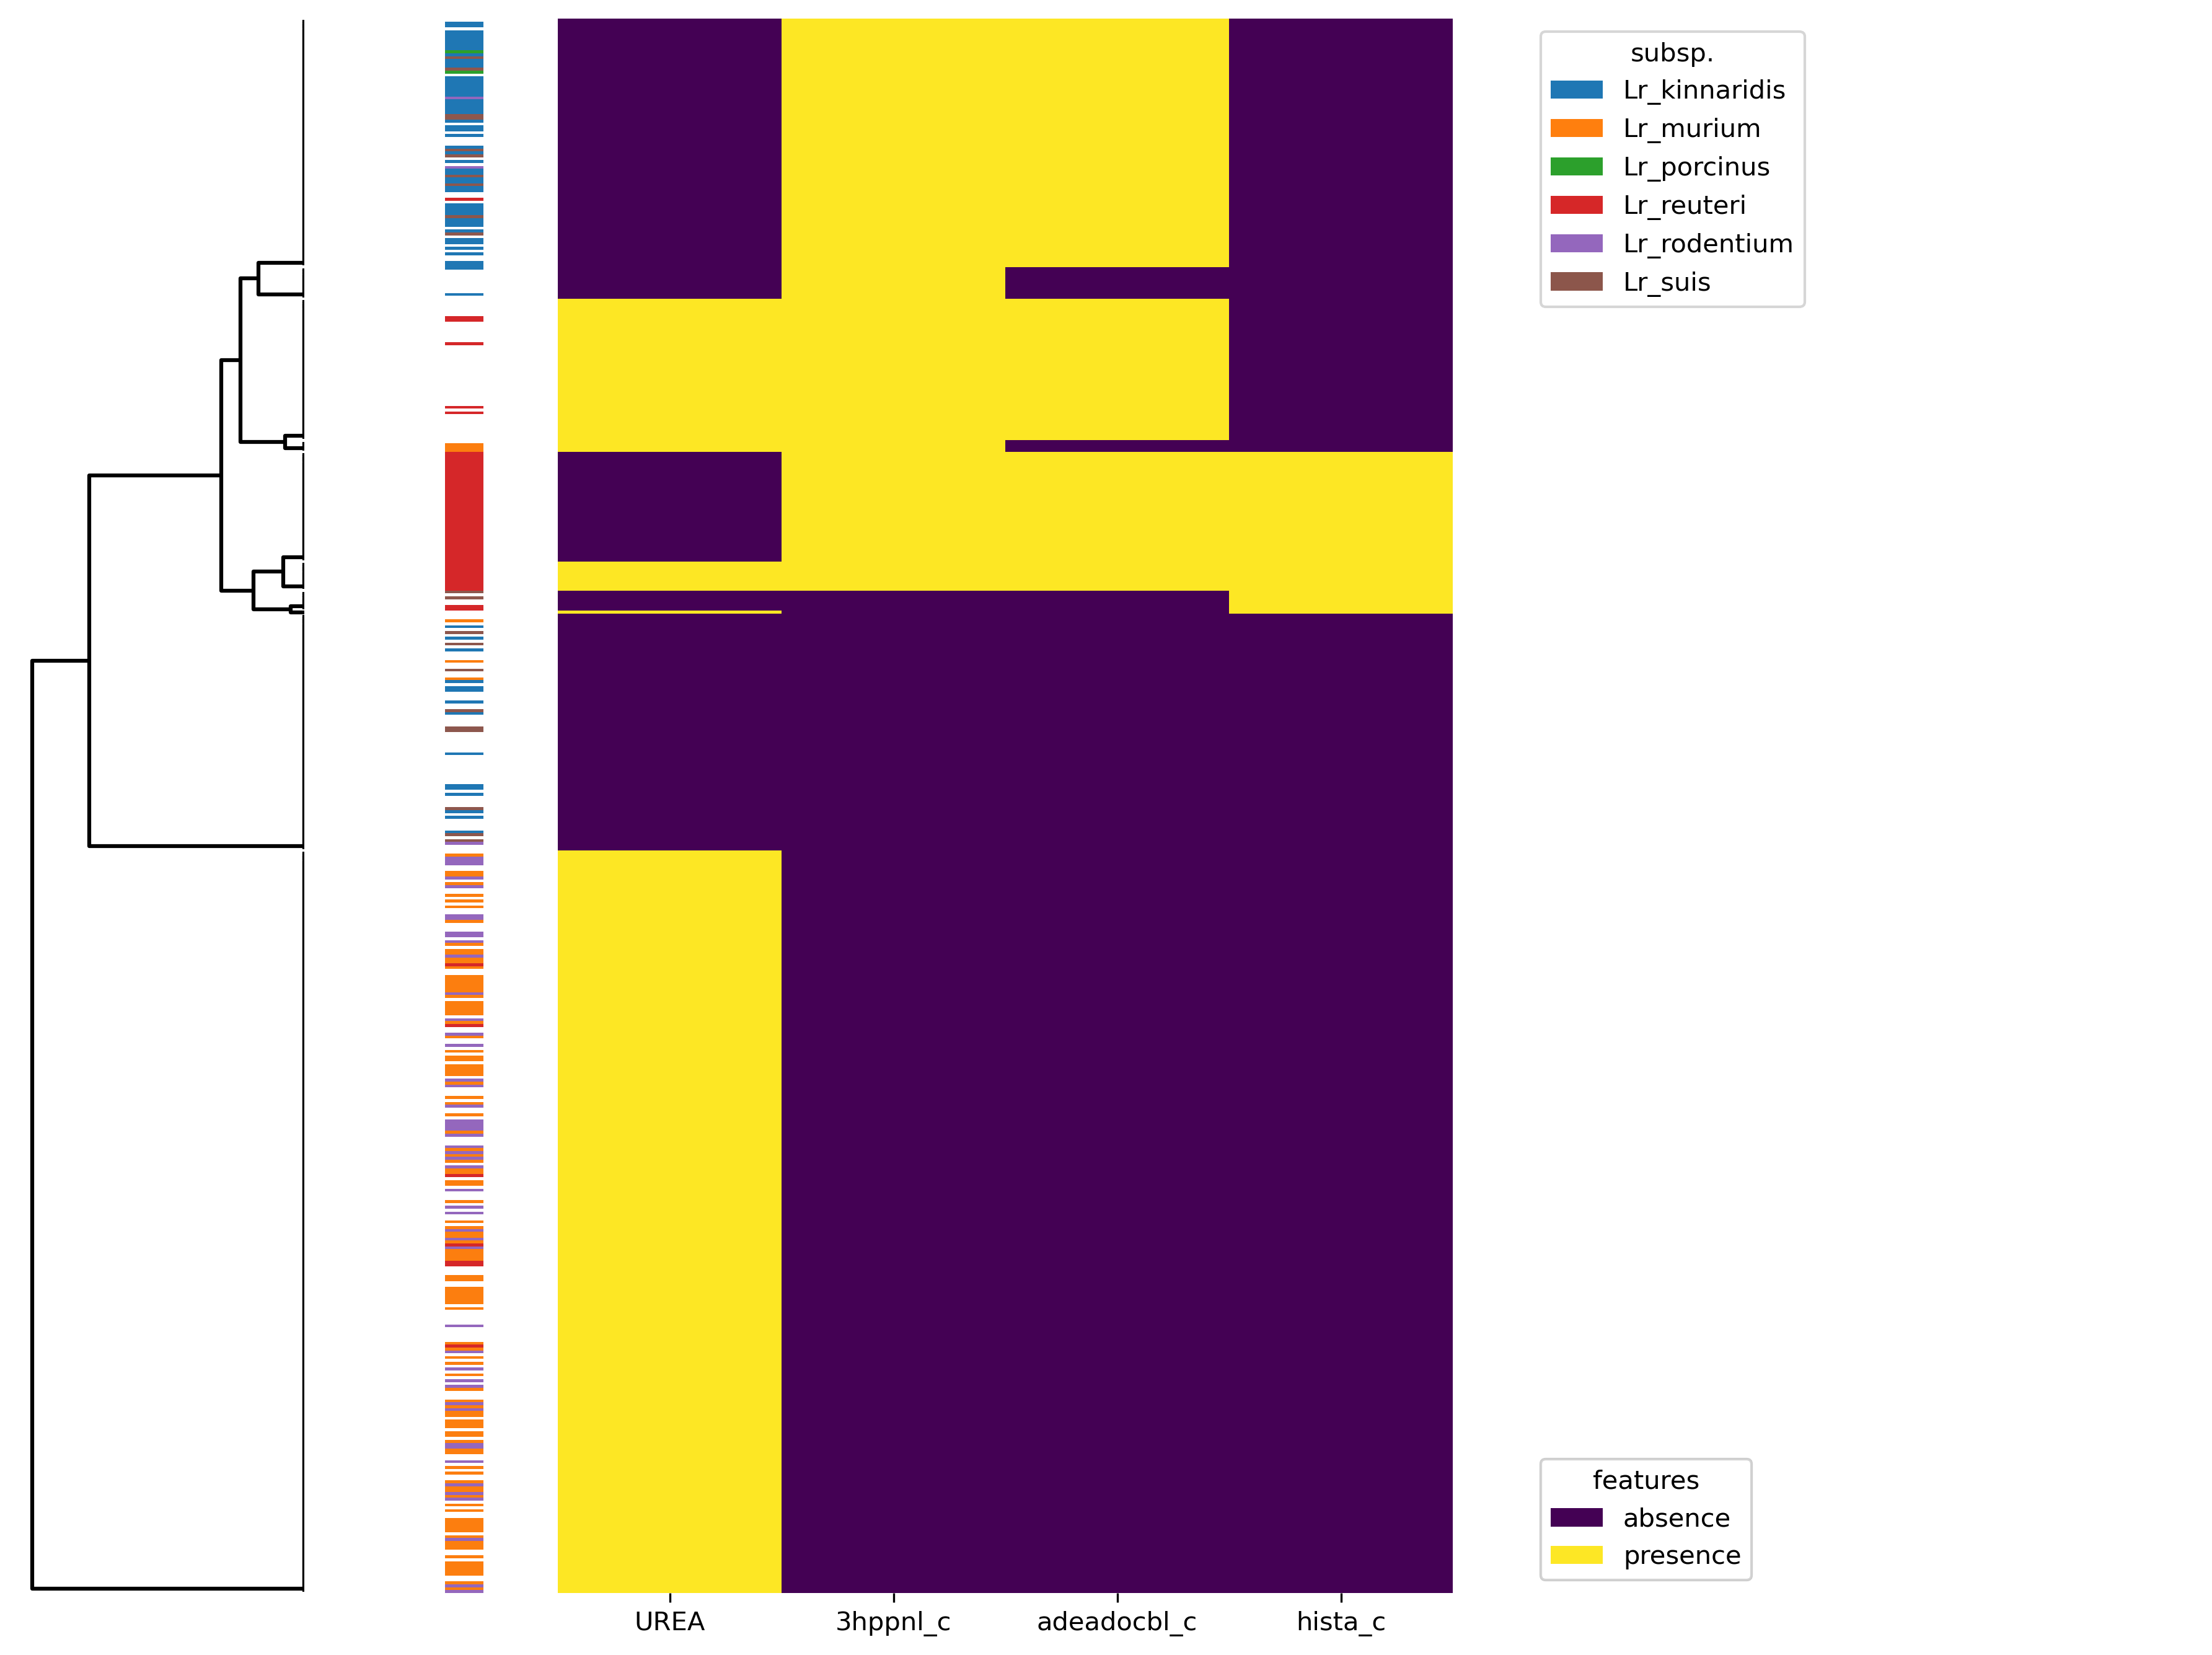

In [4]:
# Figure 6B
fig, ord_data_bool = gempipe.heatmap_multilayer(
    figsize = (12,9),  
    derive_report=report, report_key='subsp.', excludekeys=['other_Lr'],
    tables={'presence': feats},  xlabels=True,
)
fig.savefig("figures/Figure 6B.png", dpi=300)

In [10]:
from PIL import Image, ImageDraw, ImageFont, ImageChops

img_a = Image.open("figures/Figure 6A.png")
img_b = Image.open("figures/Figure 6B.png")


def trim_whitespace(img):
    width, height = img.size
    crop_box = (0, 0, int(width * 0.85), height)
    cropped_img = img.crop(crop_box)
    return cropped_img


# Remove surrounding white borders
img_a = trim_whitespace(img_a)
img_b = trim_whitespace(img_b)


total_width = img_a.width + img_b.width
max_height = max(img_a.height, img_b.height)

# create new blank (white) image with the right dimensions
combined = Image.new("RGB", (total_width, max_height), "white")

# paste images, centered
y_offset_a = (max_height - img_a.height) // 2
y_offset_b = (max_height - img_b.height) // 2
combined.paste(img_a, (0, y_offset_a))
combined.paste(img_b, (img_a.width, y_offset_b))

# add labels
draw = ImageDraw.Draw(combined)
font = ImageFont.truetype(   # 60 wits well with 300dpi
    "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf", 60)


# add "A" at top-left of 2a
draw.text((10, 10), "A", font=font, fill="black")
# add "B" at top-left of 2b (relative to its starting y position)
draw.text((img_a.width + 10, 10), "B", font=font, fill="black")

combined.save("figures/Figure 6.png", dpi=(300, 300))